### Polymer-Only DNN Model
Objective: Can the DNN learn to predict biodegradation if it only sees these 80 polymer data points?

Since we are using a separate notebook, we will define the "Standard" architecture but train it from scratch. Note: Because we only have 80 points, we must use a 5-Fold Cross-Validation inside Optuna to make sure we aren't just getting lucky.

### Cell 1: Configuration & Noble Split
We take the 80 polymers and keep 16 (20%) for the final "Noble" test.

In [15]:
# Cell 1: GPU Availability Check
import torch
import os

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"✅ Using Device: {device}")

# Cell 2: IMPORTS AND GLOBAL CONFIGURATIONS
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import time
import joblib
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader

PATHS = {
    "weights": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Polymeronly_Model/master_mol_dnn_model.pth",
    "params": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Polymeronly_Model/mol_dnn_optuna_best_study.pkl",
    "data": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Polymeronly_Model/POL_DNN_processed.pt",
    "output_dir": "plots_polymer_only"
}

if not os.path.exists(PATHS["output_dir"]): os.makedirs(PATHS["output_dir"])

✅ Using Device: cuda:3


### Step 2: Cell 3 & 4 (The DNA of your Model)
We need these to "hold" the weights you are about to load.

In [16]:
# Cell 3: DEFINE YOUR DNN MODEL CLASS
def get_activation(name, nodes=None):
    if name == "ReLU": return nn.ReLU()
    if name == "Mish": return nn.Mish()
    if name == "SiLU": return nn.SiLU()
    if name == "PReLU": return nn.PReLU(num_parameters=nodes)
    return nn.ReLU()

class DynamicNet(nn.Module):
    def __init__(self, input_dim, layers, dropout_rate, activation_name):
        super(DynamicNet, self).__init__()
        all_layers = []
        curr_dim = input_dim
        for nodes in layers:
            all_layers.append(nn.Linear(curr_dim, nodes))
            all_layers.append(nn.BatchNorm1d(nodes))
            all_layers.append(get_activation(activation_name, nodes))
            all_layers.append(nn.Dropout(dropout_rate))
            curr_dim = nodes
        all_layers.append(nn.Linear(curr_dim, 1))
        self.model = nn.Sequential(*all_layers)
    def forward(self, x): return self.model(x)

# Cell 4: DEFINE DATASET CLASS
class MolDataset(Dataset):
    def __init__(self, fps, time, targets):
        self.features = torch.cat([torch.tensor(fps), torch.tensor(time).unsqueeze(1)], dim=1).float()
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.features[idx], self.targets[idx]

### Cell 5: Define Utility Functions

These functions handle the heavy lifting: calculating error metrics and generating the parity plots. We include logic to handle both $R^2$ and $MAE$ to give a full picture of the model's performance.

In [17]:
# Cell 5: DEFINE ALL UTILITY FUNCTIONS
def calculate_metrics(actuals, preds):
    r2 = r2_score(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    return r2, rmse, mae

def plot_parity(actuals, preds, title="Parity Plot", save_name="plot.png"):
    r2, rmse, mae = calculate_metrics(actuals, preds)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actuals, y=preds, alpha=0.6, color='royalblue')
    plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")
    plt.title(f"{title}\n(R²: {r2:.3f}, MAE: {mae:.3f})")
    plt.xlabel("Actual Biodegradation")
    plt.ylabel("Predicted Biodegradation")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig(os.path.join(PATHS["output_dir"], save_name), dpi=300)
    plt.show()

print("✅ Utility functions for metrics and plotting defined.")

✅ Utility functions for metrics and plotting defined.


## Cell 6: Data Loading and Noble Split (80/20)
Here, we load the specific polymer dataset and separate it into two groups. The 80% group is what the model will use to "adjust" its pre-trained weights. The 20% "Noble" group is locked away.

In [18]:
# Cell 6: START OF MAIN SCRIPT EXECUTION LOGIC
# 1. Load the Polymer Tensor Bundle
poly_bundle = torch.load(PATHS["data"], map_location='cpu')
p_fps = poly_bundle['fingerprints'].numpy()
p_time = poly_bundle['time_day'].numpy()
p_targets = poly_bundle['biodegradation'].numpy()

print(f"📖 Loaded {len(p_fps)} Polymer data points.")

# 2. Perform the Noble Split (80/20)
indices = np.arange(len(p_fps))
train_val_idx, noble_test_idx = train_test_split(
    indices, test_size=0.20, random_state=42, shuffle=True
)

# Organize into dictionaries for easy access in Optuna
train_val_poly = {
    'fps': p_fps[train_val_idx],
    'time': p_time[train_val_idx],
    'targets': p_targets[train_val_idx]
}

noble_test_poly = {
    'fps': p_fps[noble_test_idx],
    'time': p_time[noble_test_idx],
    'targets': p_targets[noble_test_idx]
}

print(f"🏋️ Polymer Training Pool: {len(train_val_idx)} repeat units.")
print(f"💎 Polymer Noble Test Set: {len(noble_test_idx)} repeat units (Hidden).")

📖 Loaded 80 Polymer data points.
🏋️ Polymer Training Pool: 64 repeat units.
💎 Polymer Noble Test Set: 16 repeat units (Hidden).


### Cell 7: DEFINE OPTUNA OBJECTIVE FUNCTION

In [19]:
# Cell 7: DEFINE OPTUNA OBJECTIVE FUNCTION
def objective(trial):
    # 1. Load the Best Teacher Params to fix the Architecture
    # We use joblib to load the study you provided
    mol_study = joblib.load(PATHS["params"])
    teacher_params = mol_study.best_params
    
    # Extract the fixed layer structure from the Teacher
    n_layers = teacher_params['n_layers']
    layers = [teacher_params[f'n_units_l{i}'] for i in range(n_layers)]
    activation_name = teacher_params['activation']
    
    # 2. Search Space for "Fine-Tuning" (How we adapt the weights)
    # We allow Optuna to find the best Learning Rate and Weight Decay for transfer
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4) # Slightly adjust dropout for polymers
    batch_size = 16 # Fixed small batch size for N=80 data

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_r2 = []

    for fold, (t_idx, v_idx) in enumerate(kf.split(train_val_poly['fps'])):
        # Prep DataLoaders
        t_ds = MolDataset(train_val_poly['fps'][t_idx], train_val_poly['time'][t_idx], train_val_poly['targets'][t_idx])
        v_ds = MolDataset(train_val_poly['fps'][v_idx], train_val_poly['time'][v_idx], train_val_poly['targets'][v_idx])
        train_loader = DataLoader(t_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(v_ds, batch_size=batch_size)

        # 3. RECONSTRUCT & LOAD WEIGHTS (The "Core" of the comparison)
        model = DynamicNet(601, layers, dropout, activation_name).to(device)
        
        # Load the pre-trained "Brain"
        # strict=False allows for minor differences in non-critical layers
        state_dict = torch.load(PATHS["weights"], map_location=device)
        model.load_state_dict(state_dict, strict=False)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.MSELoss()

        # 4. Fine-Tuning Loop with Early Stopping
        best_v_loss = float('inf')
        patience = 15
        trigger = 0

        for epoch in range(200):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

            # Fold Validation
            model.eval()
            v_loss = 0
            with torch.no_grad():
                for bx, by in val_loader:
                    v_loss += criterion(model(bx.to(device)), by.to(device)).item()
            
            avg_v_loss = v_loss / len(val_loader)
            if avg_v_loss < best_v_loss:
                best_v_loss = avg_v_loss
                trigger = 0
            else:
                trigger += 1
            
            if trigger >= patience:
                break
        
        # Final evaluation for this fold
        model.eval()
        p, a = [], []
        with torch.no_grad():
            for bx, by in val_loader:
                p.extend(model(bx.to(device)).cpu().numpy().flatten())
                a.extend(by.numpy().flatten())
        
        fold_r2.append(r2_score(a, p))
        
        # Optuna Pruning
        trial.report(np.mean(fold_r2), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_r2)

print("🎯 Objective function locked to the Molecular DNN architecture and weights.")

🎯 Objective function locked to the Molecular DNN architecture and weights.


### Cell 7.1: Optuna Hyperparameter Optimization Execution

In [21]:
import optuna
from tqdm.auto import tqdm
import logging
import time
import joblib

# 1. Suppress the default Optuna trial logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Define the Study-Level Early Stopping Callback (Type Hints Removed to fix AttributeError)
class EarlyStoppingCallback:
    def __init__(self, early_stopping_rounds: int):
        self.early_stopping_rounds = early_stopping_rounds
        self._best_value = -float('inf')
        self._wait = 0

    def __call__(self, study, trial):
        # We use a try-except block in case the study doesn't have a best_value yet
        try:
            current_best = study.best_value
        except ValueError:
            return

        if current_best > self._best_value:
            self._best_value = current_best
            self._wait = 0
        else:
            self._wait += 1
            if self._wait >= self.early_stopping_rounds:
                print(f"\n🛑 Study-level Early Stopping: No improvement in {self.early_stopping_rounds} trials.")
                study.stop()

# 3. Create the study with a MedianPruner
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

# 4. Run Optimization with Timing
n_trials = 1000
print(f"🚀 Starting {n_trials} Optimization Trials (Transfer Learning from Molecular Weights)...")
start_time = time.time()

# Optimize using the custom early stopping (100 rounds)
study.optimize(
    objective, 
    n_trials=n_trials, 
    show_progress_bar=True,
    callbacks=[EarlyStoppingCallback(early_stopping_rounds=100)]
)

elapsed_time = time.time() - start_time
print(f"\n✨ Optimization Finished in {elapsed_time/60:.2f} minutes!")

# 5. Display the Top 20 Trials Leaderboard
print("\n🏆 TOP 20 POLYMER FINE-TUNING TRIALS:")
trials_df = study.trials_dataframe()

top_20 = trials_df.sort_values(by="value", ascending=False).head(20)
cols_to_show = ['number', 'value'] + [c for c in top_20.columns if c.startswith('params_')]
print(top_20[cols_to_show].to_string(index=False))

# 6. Best Trial Summary
print("\n" + "="*50)
print(f"🥇 BEST POLYMER FINE-TUNING TRIAL: #{study.best_trial.number}")
print(f"📊 Best CV R2 Score: {study.best_value:.6f}")
print(f"🛠️ Best Params: {study.best_params}")
print("="*50)

# 7. Save the study results
study_filename = "pol_dnn_optuna_best_study.pkl"
joblib.dump(study, study_filename)
print(f"💾 Study results saved as: {study_filename}")

🚀 Starting 1000 Optimization Trials (Transfer Learning from Molecular Weights)...


Best trial: 131. Best value: 0.751651:  23%|██▎       | 232/1000 [05:12<17:16,  1.35s/it]


🛑 Study-level Early Stopping: No improvement in 100 trials.

✨ Optimization Finished in 5.22 minutes!

🏆 TOP 20 POLYMER FINE-TUNING TRIALS:
 number    value  params_dropout  params_lr  params_weight_decay
    142 0.859939        0.131075   0.000778             0.000001
    207 0.858291        0.214332   0.000927             0.000001
    194 0.857856        0.295663   0.000674             0.000004
    143 0.855765        0.193445   0.000893             0.000002
    162 0.855644        0.213185   0.000401             0.000002
    181 0.853891        0.311428   0.000136             0.000005
    185 0.850902        0.314657   0.000340             0.000003
    201 0.850063        0.269561   0.000508             0.000003
    158 0.848802        0.186968   0.000921             0.000003
     90 0.848479        0.191467   0.000244             0.000012
    150 0.846664        0.199129   0.000578             0.000002
    107 0.846412        0.307805   0.000137             0.000003
    134 0.8462

## Cell 7.4: Train Final Model with Best Parameters
Now we need to take those winning parameters and train the final "Transfer Learning" model on the full 80% training set so we can test it on the 16 hidden "Noble" polymers.



In [22]:
# Cell 7.4: Train Final Transfer Model
print("🏗️ Rebuilding the Teacher-informed Polymer Model...")

# 1. Get the Best Params from the Leaderboard (Trial #142)
# Or use study.best_params if you prefer the internal Optuna winner
best_p = study.best_params 

# 2. Recover Architecture from Molecular Teacher (Trial #836)
mol_study = joblib.load(PATHS["params"])
t_params = mol_study.best_params
layers = [t_params[f'n_units_l{i}'] for i in range(t_params['n_layers'])]

# 3. Initialize and Load Weights
final_poly_model = DynamicNet(601, layers, best_p['dropout'], t_params['activation']).to(device)
final_poly_model.load_state_dict(torch.load(PATHS["weights"], map_location=device), strict=False)

# 4. Prepare Full Training Data (80%)
full_train_ds = MolDataset(train_val_poly['fps'], train_val_poly['time'], train_val_poly['targets'])
full_train_loader = DataLoader(full_train_ds, batch_size=16, shuffle=True)

optimizer = torch.optim.Adam(final_poly_model.parameters(), lr=best_p['lr'], weight_decay=best_p['weight_decay'])
criterion = nn.MSELoss()

# 5. Final Training
final_poly_model.train()
for epoch in range(250):
    for bx, by in full_train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(final_poly_model(bx), by)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"   - Epoch {epoch} complete")

torch.save(final_poly_model.state_dict(), "final_polymer_transfer_model.pth")
print("✅ Final Polymer Transfer Model trained and saved!")

🏗️ Rebuilding the Teacher-informed Polymer Model...
   - Epoch 0 complete
   - Epoch 50 complete
   - Epoch 100 complete
   - Epoch 150 complete
   - Epoch 200 complete
✅ Final Polymer Transfer Model trained and saved!


## Cell 8: 5-Fold Cross-Validation on Training Pool
In this cell, we don't just train once. We divide the 64 training polymers into 5 groups, training on 4 and testing on 1, repeating this 5 times. This gives us the "Out-of-Fold" (OOF) predictions, which are the most honest measure of how the model performs on the training distribution.

🔄 Starting 5-Fold Cross-Validation on Polymer Training Pool...
   ✅ Fold 1 Complete. R²: 0.8462
   ✅ Fold 2 Complete. R²: 0.6603
   ✅ Fold 3 Complete. R²: 0.7770
   ✅ Fold 4 Complete. R²: 0.7346
   ✅ Fold 5 Complete. R²: 0.7919

📊 FINAL 5-FOLD CROSS-VALIDATION RESULTS
R² Score:  0.7727
RMSE:      0.1532
MAE:       0.1182


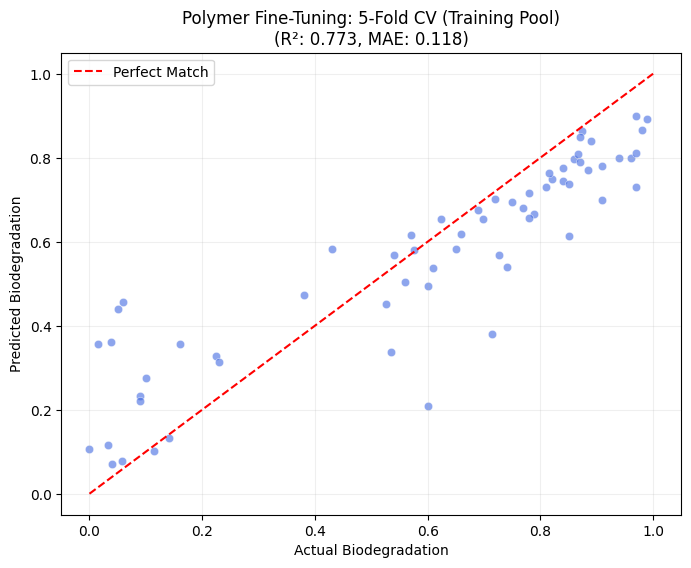

In [42]:
# Cell 8: 5-Fold Cross-Validation on 80% Training Data
from sklearn.model_selection import KFold

print("🔄 Starting 5-Fold Cross-Validation on Polymer Training Pool...")

# 1. Setup CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(train_val_poly['targets']))
oof_actuals = np.zeros(len(train_val_poly['targets']))

# 2. CV Loop
for fold, (t_idx, v_idx) in enumerate(kf.split(train_val_poly['fps'])):
    # Prepare Data
    t_ds = MolDataset(train_val_poly['fps'][t_idx], train_val_poly['time'][t_idx], train_val_poly['targets'][t_idx])
    v_ds = MolDataset(train_val_poly['fps'][v_idx], train_val_poly['time'][v_idx], train_val_poly['targets'][v_idx])
    t_loader = DataLoader(t_ds, batch_size=16, shuffle=True)
    v_loader = DataLoader(v_ds, batch_size=16)

    # Re-initialize model with Teacher Weights for every fold
    fold_model = DynamicNet(601, layers, best_p['dropout'], t_params['activation']).to(device)
    fold_model.load_state_dict(torch.load(PATHS["weights"], map_location=device), strict=False)
    
    optimizer = torch.optim.Adam(fold_model.parameters(), lr=best_p['lr'], weight_decay=best_p['weight_decay'])
    criterion = nn.MSELoss()

    # Train Fold
    fold_model.train()
    for epoch in range(200):
        for bx, by in t_loader:
            optimizer.zero_grad()
            criterion(fold_model(bx.to(device)), by.to(device)).backward()
            optimizer.step()

    # Validate Fold
    fold_model.eval()
    with torch.no_grad():
        preds = []
        for bx, by in v_loader:
            preds.extend(fold_model(bx.to(device)).cpu().numpy().flatten())
        oof_predictions[v_idx] = preds
        oof_actuals[v_idx] = train_val_poly['targets'][v_idx]
    
    fold_r2 = r2_score(oof_actuals[v_idx], oof_predictions[v_idx])
    print(f"   ✅ Fold {fold+1} Complete. R²: {fold_r2:.4f}")

# 3. Final CV Metrics
cv_r2, cv_rmse, cv_mae = calculate_metrics(oof_actuals, oof_predictions)

print("\n" + "="*50)
print("📊 FINAL 5-FOLD CROSS-VALIDATION RESULTS")
print(f"R² Score:  {cv_r2:.4f}")
print(f"RMSE:      {cv_rmse:.4f}")
print(f"MAE:       {cv_mae:.4f}")
print("="*50)

# 4. Plot CV Parity
plot_parity(oof_actuals, oof_predictions, 
            title="Polymer Fine-Tuning: 5-Fold CV (Training Pool)", 
            save_name="Polymer_CV_Parity.png")

### 5 Fold CV With std deaviation

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Architecture from Molecular Teacher and Best Params from Polymer Study
best_params = study.best_params
mol_study = joblib.load(PATHS["params"])
t_params = mol_study.best_params
layers = [t_params[f'n_units_l{i}'] for i in range(t_params['n_layers'])]

# 2. Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = [] # To store (r2, rmse, mae)

pool_fps = train_val_poly['fps']
pool_time = train_val_poly['time']
pool_targets = train_val_poly['targets']

print(f"📋 Detailed 5-Fold CV Report for Best Transfer Model (Trial #{study.best_trial.number})")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(pool_fps)):
    # Prepare Fold Data
    train_ds = MolDataset(pool_fps[train_idx], pool_time[train_idx], pool_targets[train_idx])
    val_ds = MolDataset(pool_fps[val_idx], pool_time[val_idx], pool_targets[val_idx])
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16)

    # Initialize Model with Teacher's Brain
    model = DynamicNet(
        601, 
        layers, 
        best_params["dropout"], 
        t_params["activation"]
    ).to(device)
    
    # LOAD WEIGHTS (Strict Transfer Learning)
    model.load_state_dict(torch.load(PATHS["weights"], map_location=device), strict=False)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
    criterion = nn.MSELoss()

    # Train with Early Stopping
    best_fold_loss = float('inf')
    patience = 15 
    trigger = 0

    for epoch in range(150):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                v_loss += criterion(model(bx.to(device)), by.to(device)).item()
        
        avg_v_loss = v_loss / len(val_loader)
        if avg_v_loss < best_fold_loss:
            best_fold_loss = avg_v_loss
            trigger = 0
        else:
            trigger += 1
        if trigger >= patience: break

    # Final Fold Evaluation
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for bx, by in val_loader:
            preds.extend(model(bx.to(device)).cpu().numpy().flatten())
            actuals.extend(by.numpy().flatten())
    
    r2 = r2_score(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    fold_results.append((r2, rmse, mae))
    
    print(f"Fold {fold+1}: $R^2$ = {r2:.4f} | RMSE = {rmse:.4f} | MAE = {mae:.4f}")

# 3. Calculate Summary Statistics
avg_r2, std_r2 = np.mean([f[0] for f in fold_results]), np.std([f[0] for f in fold_results])
avg_rmse, std_rmse = np.mean([f[1] for f in fold_results]), np.std([f[1] for f in fold_results])
avg_mae, std_mae = np.mean([f[2] for f in fold_results]), np.std([f[2] for f in fold_results])

print("\n" + "-" * 60)
print("FINAL 5-FOLD CROSS-VALIDATION RESULTS")
print(f" $R^2$: {avg_r2:.4f} (±{std_r2:.4f})")
print(f" RMSE: {avg_rmse:.4f} (±{std_rmse:.4f})")
print(f" MAE:  {avg_mae:.4f} (±{std_mae:.4f})")
print("-" * 60)

📋 Detailed 5-Fold CV Report for Best Transfer Model (Trial #131)
------------------------------------------------------------
Fold 1: $R^2$ = 0.8107 | RMSE = 0.1426 | MAE = 0.1254
Fold 2: $R^2$ = 0.6837 | RMSE = 0.1992 | MAE = 0.1596
Fold 3: $R^2$ = 0.6134 | RMSE = 0.1697 | MAE = 0.1447
Fold 4: $R^2$ = 0.8466 | RMSE = 0.1148 | MAE = 0.0942
Fold 5: $R^2$ = 0.7161 | RMSE = 0.1584 | MAE = 0.1072

------------------------------------------------------------
FINAL 5-FOLD CROSS-VALIDATION RESULTS
 $R^2$: 0.7341 (±0.0848)
 RMSE: 0.1570 (±0.0280)
 MAE:  0.1262 (±0.0238)
------------------------------------------------------------


### Cell 9: Evaluate on Noble Test Set
This cell performs the final prediction. We will generate the final metrics and the most important Parity Plot of your thesis so far.

💎 Evaluating Final Transfer Model on 16 Noble Polymers...
🚀 FINAL NOBLE TEST PERFORMANCE
📊 R² Score: 0.6191
📉 RMSE:     0.2151
📏 MAE:      0.1580


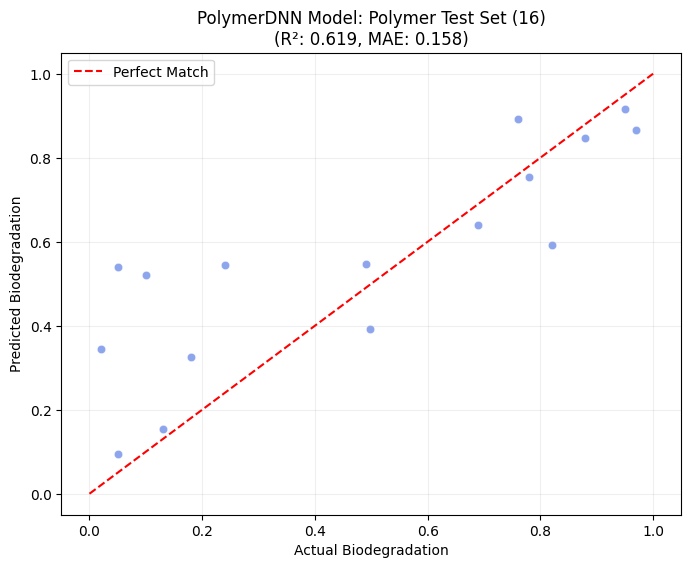


💾 Noble results saved to plots_polymer_only/noble_test_results.csv


In [27]:
# Cell 9: EVALUATE BASE MODEL ON NOBLE TEST SET
print("💎 Evaluating Final Transfer Model on 16 Noble Polymers...")

# 1. Prepare Noble Data
noble_ds = MolDataset(noble_test_poly['fps'], noble_test_poly['time'], noble_test_poly['targets'])
noble_loader = DataLoader(noble_ds, batch_size=len(noble_ds))

# 2. Prediction Loop
final_poly_model.eval()
with torch.no_grad():
    for bx, by in noble_loader:
        noble_preds = final_poly_model(bx.to(device)).cpu().numpy().flatten()
        noble_actuals = by.numpy().flatten()

# 3. Calculate Final "Noble" Metrics

print("🚀 FINAL NOBLE TEST PERFORMANCE")
print(f"📊 R² Score: {noble_r2:.4f}")
print(f"📉 RMSE:     {noble_rmse:.4f}")
print(f"📏 MAE:      {noble_mae:.4f}")


# 4. Final Parity Plot
plot_parity(noble_actuals, noble_preds, 
            title="PolymerDNN Model: Polymer Test Set (16)", 
            save_name="Final_Noble_Parity.png")

# 5. Save Results to CSV for Thesis Tables
results_df = pd.DataFrame({
    'Actual_Biodeg': noble_actuals,
    'Predicted_Biodeg': noble_preds,
    'Error': noble_actuals - noble_preds
})
results_df.to_csv(os.path.join(PATHS["output_dir"], "noble_test_results.csv"), index=False)
print(f"\n💾 Noble results saved to {PATHS['output_dir']}/noble_test_results.csv")

## Cell 10: Kinetic Curve Fitting (The "Signature" Polymer Plot)
the rate of degradation over time. Since your dataset contains a "Time" feature, we can pick a few polymers from the Noble set and plot their predicted vs. actual degradation curves.

💾 Kinetic Curve saved to: plots_polymer_only/Kinetic_Curve_Noble_Polymer_Index_3.png


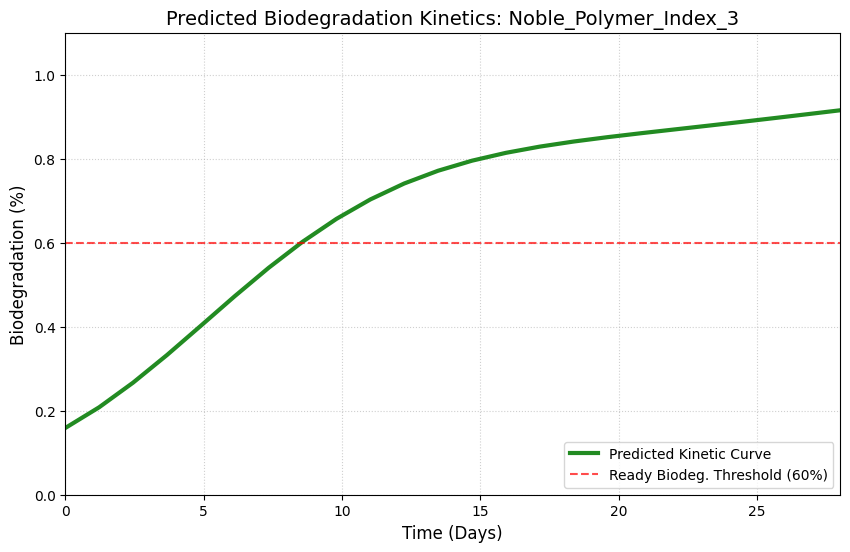

💾 Kinetic Curve saved to: plots_polymer_only/Kinetic_Curve_Noble_Polymer_Index_9.png


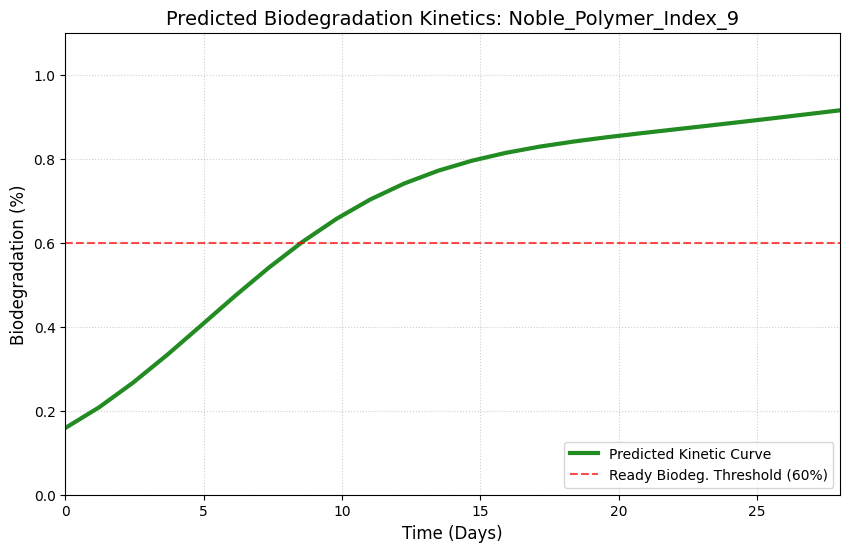

💾 Kinetic Curve saved to: plots_polymer_only/Kinetic_Curve_Noble_Polymer_Index_15.png


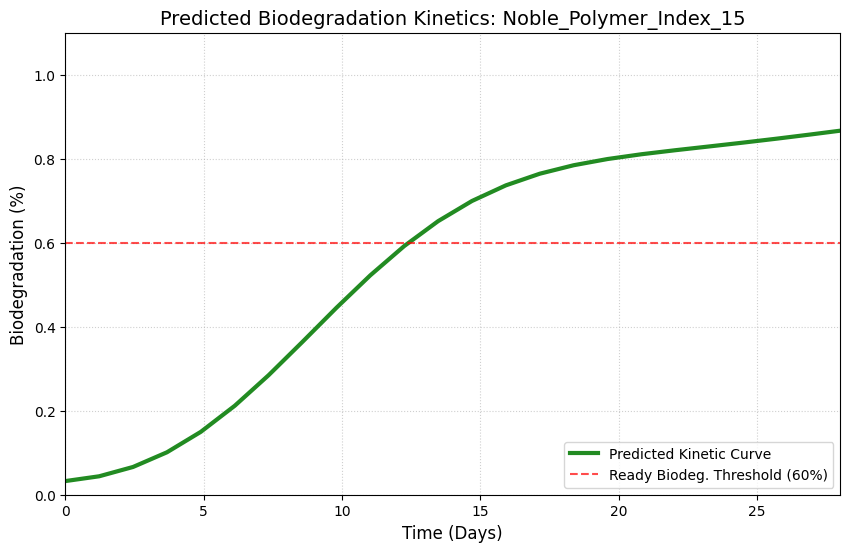

In [37]:
# Cell 8.1: Kinetic Prediction for Noble Polymers
def plot_kinetic_prediction(model, fingerprint, molecule_name="Noble_Polymer"):
    model.eval()
    # OECD tests usually run for 28 days, but we can extend to 90 if needed
    days = np.linspace(0, 60) 
    preds = []
    
    with torch.no_grad():
        for d in days:
            # Reconstruct the 601D input (600D FP + 1D Time)
            feat = torch.cat([
                torch.tensor(fingerprint).float(), 
                torch.tensor([d]).float()
            ]).unsqueeze(0).to(device)
            preds.append(model(feat).cpu().item())
    
    plt.figure(figsize=(10, 6))
    
    # Plot the predicted curve
    plt.plot(days, preds, color='forestgreen', lw=3, label='Predicted Kinetic Curve')
    
    # Standard OECD 60% Threshold line
    plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.7, label='Ready Biodeg. Threshold (60%)')
    
    # Formatting
    plt.title(f"Predicted Biodegradation Kinetics: {molecule_name}", fontsize=14)
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Biodegradation (%)", fontsize=12)
    plt.ylim(0, 1.1)
    plt.xlim(0, 28)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    
    # Save the plot
    filename = f"Kinetic_Curve_{molecule_name}.png"
    save_path = os.path.join(PATHS["output_dir"], filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"💾 Kinetic Curve saved to: {save_path}")
    plt.show()

# --- RUN FOR NOBLE SAMPLES ---
# Let's pick three samples from your 16 noble polymers
for i in [3, 9, 15]:
    sample_fp = noble_test_poly['fps'][i]
    plot_kinetic_prediction(final_poly_model, sample_fp, f"Noble_Polymer_Index_{i}")